# SILVA Physics Graph Equilibrium: Transport Dataset Lab

This lab derives graph diffusion and directed transport, verifies a generated
steady-state dataset, trains a node-level SILVA equilibrium, and tests node
relabeling. The canonical family is `silva_physics_graph_deq` [[44]](https://jseluis.github.io/silva-networks/paper/references/#ref-44).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[36]](https://jseluis.github.io/silva-networks/paper/references/#ref-36), [[44]](https://jseluis.github.io/silva-networks/paper/references/#ref-44). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

from silva_networks import (
    SILVAPhysicsGuidedGraphDEQ,
    SolverConfig,
    graph_convection_diffusion,
    make_graph_transport_dataset,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(180)

## 1. Continuous and Discrete Transport

A steady convection-diffusion-reaction equation can be written

$$
0=s+\gamma_r u+\gamma_d\Delta u
-\gamma_a\mathbf v\cdot\nabla u-u.
$$

For incoming edge $i\rightarrow j$, SILVA uses

$$
(\mathcal L_GZ)_j
=\frac1{d_j}\sum_{i\rightarrow j}
w_{ij}(Z_i-Z_j),
$$

$$
(\nabla_VZ)_j
=\frac1{d_j}\sum_{i\rightarrow j}
v_{ij}(Z_j-Z_i).
$$

The first is symmetric when conductances and reverse edges agree. The second
retains orientation through the signed edge velocity [[44]](https://jseluis.github.io/silva-networks/paper/references/#ref-44).

In [3]:
data = make_graph_transport_dataset(
    samples=4,
    nodes=10,
    reaction_scale=0.05,
    diffusion_scale=0.2,
    advection_scale=0.05,
    seed=18,
)
physical_error = data.equation_residual().abs().max()

assert data.x.shape == (40, 3)
assert data.edge_index.shape == (2, 80)
assert physical_error < 2e-6
print("nodes:", data.x.shape[0])
print("graphs:", int(data.batch.max()) + 1)
print("maximum dataset equation residual:", float(physical_error))

nodes: 40
graphs: 4
maximum dataset equation residual: 1.1920928955078125e-07


## 2. SILVA Branch Equation

Node observations $X$ enter the source branch. Reaction, diffusion, and
advection receive distinct learned channel maps:

$$
\begin{aligned}
T(Z;X)
&=\phi\left[S(X)+\gamma_rR(Z)\right.\\
&\qquad+\gamma_dD(\mathcal L_GZ)\\
&\qquad\left.-\gamma_aA(\nabla_VZ)\right].
\end{aligned}
$$

The node equilibrium is $Z^\star=T(Z^\star;X)$. A node readout predicts one
value per node; graph pooling is applied only when the task has one target per
graph.

In [4]:
probe = torch.arange(10, dtype=torch.float32).unsqueeze(-1)
one_graph_edges = data.edge_index[:, :20]
diffusion, gradient = graph_convection_diffusion(
    probe,
    one_graph_edges,
    edge_weight=data.edge_weight[:20],
    edge_velocity=data.edge_velocity[:20],
)
print("diffusion shape:", tuple(diffusion.shape))
print("directed-gradient shape:", tuple(gradient.shape))
print("constant-field diffusion check:", float(
    graph_convection_diffusion(torch.ones_like(probe), one_graph_edges)[0].abs().max()
))

diffusion shape: (10, 1)
directed-gradient shape: (10, 1)
constant-field diffusion check: 0.0


## 3. Train a Small Node Field

The dataset target solves the discrete linear equation exactly. The learned
transition is nonlinear, so training asks the SILVA equilibrium and readout to
approximate that solution operator over four source fields.

In [5]:
model = SILVAPhysicsGuidedGraphDEQ(
    in_dim=3,
    state_dim=6,
    out_dim=1,
    config=SolverConfig(
        solver="picard",
        max_iter=7,
        tol=1e-5,
        alpha=0.7,
        backward_mode="unrolled",
    ),
)
optimizer = torch.optim.Adam(model.parameters(), lr=4e-3)
losses = []
for epoch in range(6):
    optimizer.zero_grad()
    prediction = model(
        data.x,
        data.edge_index,
        edge_weight=data.edge_weight,
        edge_velocity=data.edge_velocity,
    )
    loss = torch.nn.functional.mse_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

result = model(
    data.x,
    data.edge_index,
    edge_weight=data.edge_weight,
    edge_velocity=data.edge_velocity,
    return_result=True,
)
assert result.output.shape == data.target.shape
assert all(torch.isfinite(torch.tensor(losses)))
print("training losses:", losses)
print("fixed-point residual:", result.solver_result.residual)
print("prediction physical residual:", float(
    data.equation_residual(result.output).square().mean().sqrt()
))

training losses: [0.7732363939285278, 0.7518482804298401, 0.7311099767684937, 0.7110251188278198, 0.691594123840332, 0.6728144884109497]
fixed-point residual: 0.00538542540743947
prediction physical residual: 0.8046050667762756


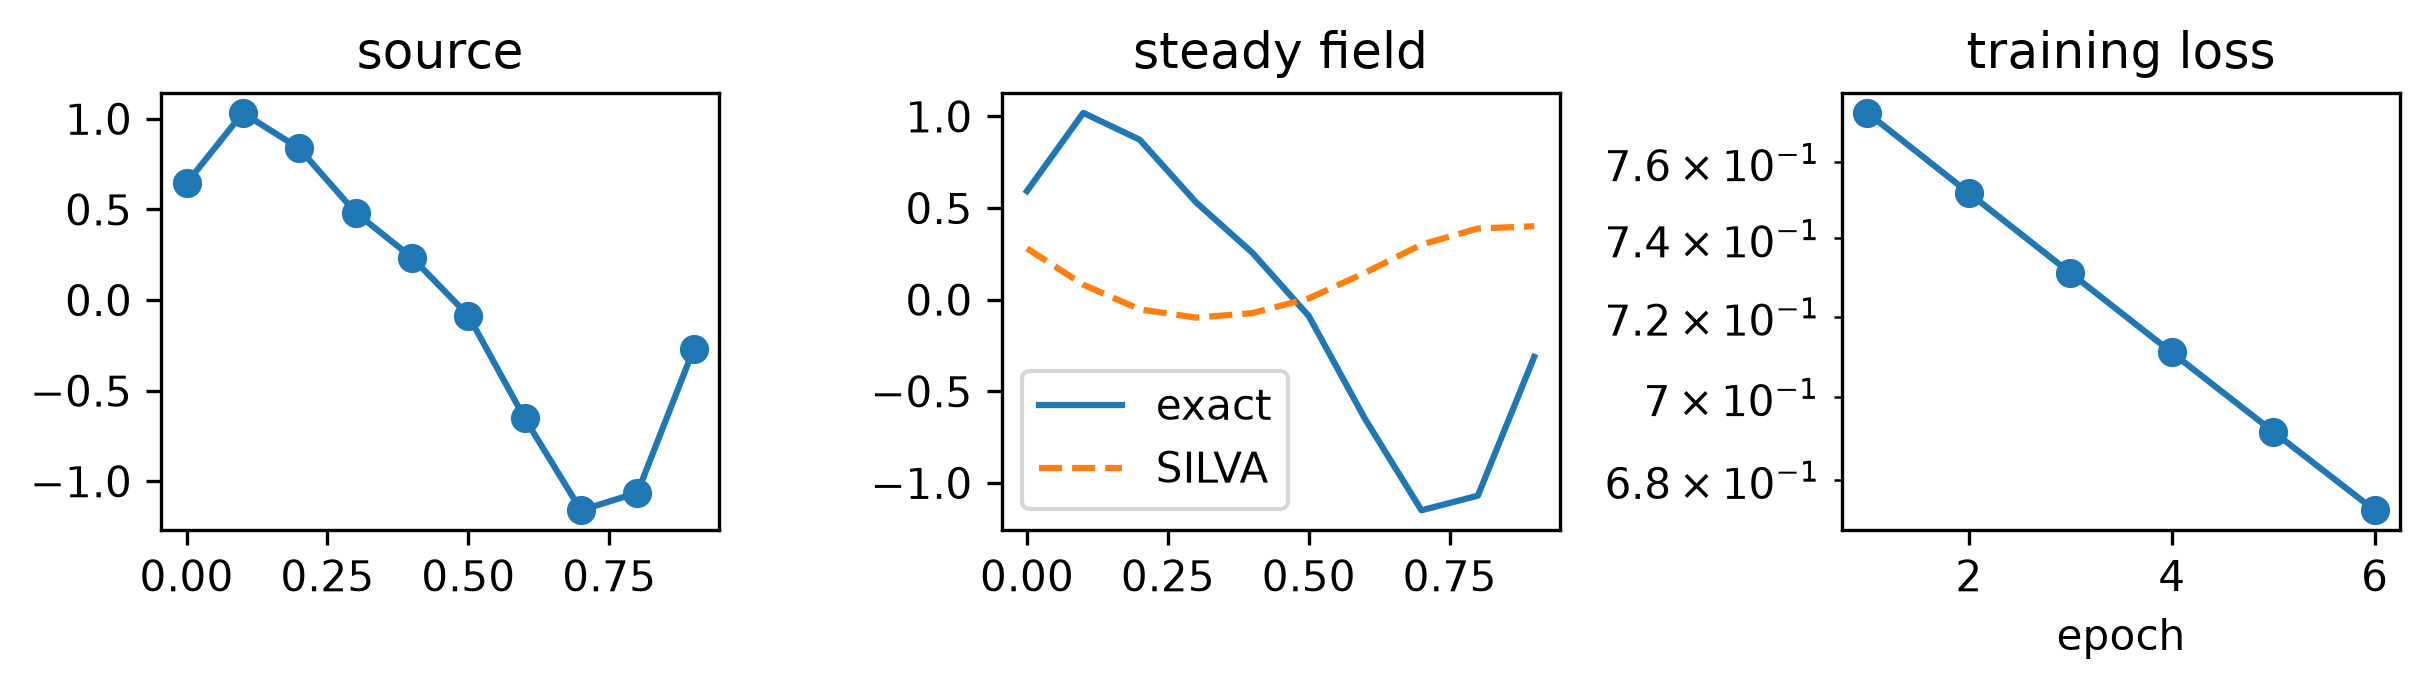

In [6]:
nodes = 10
fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.4))
axes[0].plot(data.coordinates[:nodes, 0], data.x[:nodes, 0], marker="o")
axes[0].set_title("source")
axes[1].plot(data.coordinates[:nodes, 0], data.target[:nodes, 0], label="exact")
axes[1].plot(
    data.coordinates[:nodes, 0],
    result.output[:nodes, 0].detach(),
    "--",
    label="SILVA",
)
axes[1].legend()
axes[1].set_title("steady field")
axes[2].plot(range(1, len(losses) + 1), losses, marker="o")
axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_title("training loss")
fig.tight_layout()
plt.show()

## 4. Node Relabeling

Let $P$ be a node permutation. A graph transition should satisfy

$$
T(PZ;PX,PE)=P\,T(Z;X,E),
$$

where $PE$ means that both rows of `edge_index` are relabeled consistently.
This is a structural test, not a statistical expectation.

In [7]:
single_x = data.x[:10]
single_edges = data.edge_index[:, :20]
single_weight = data.edge_weight[:20]
single_velocity = data.edge_velocity[:20]
baseline = model(
    single_x,
    single_edges,
    edge_weight=single_weight,
    edge_velocity=single_velocity,
)
permutation = torch.tensor([3, 0, 8, 1, 6, 2, 9, 5, 7, 4])
inverse = torch.empty_like(permutation)
inverse[permutation] = torch.arange(permutation.numel())
permuted_edges = inverse[single_edges]
permuted = model(
    single_x[permutation],
    permuted_edges,
    edge_weight=single_weight,
    edge_velocity=single_velocity,
)
relabel_error = (permuted - baseline[permutation]).abs().max()
assert relabel_error < 2e-5
print("node relabeling error:", float(relabel_error))

node relabeling error: 0.0


## 5. Node Tasks and Graph Tasks

For node prediction, the readout receives every equilibrium node. For graph
prediction, SILVA first computes a mask-free `mean`, `sum`, or `max` pooling
inside each graph id. Choose pooling from the units of the target: means are
intensive, sums are extensive, and maxima represent extremes.

In [8]:
graph_model = silva_equilibrium_model(
    "silva_physics_graph_deq",
    in_dim=3,
    state_dim=4,
    out_dim=1,
    task="graph",
    pooling="mean",
    config=SolverConfig(max_iter=4, alpha=0.7),
)
graph_values = graph_model(
    data.x,
    data.edge_index,
    edge_weight=data.edge_weight,
    edge_velocity=data.edge_velocity,
    batch=data.batch,
)
assert graph_values.shape == (4, 1)
print("graph-level output:", tuple(graph_values.shape))

graph-level output: (4, 1)


## 6. Practical Guidance

| Problem | Diagnostic | Response |
|---|---|---|
| transport direction is reversed | inspect one directed edge by hand | document `source -> destination` and velocity sign |
| node values oversmooth | compare reaction, diffusion, and transport ablations | reduce diffusion or retain source injection |
| graph residual is low but physics residual is high | evaluate the discrete equation separately | constrain or supervise the physical branches |
| batched graphs interact accidentally | compare graph ids at both edge endpoints | offset edges and validate every batch |

The small ring dataset tests the implementation and physical bookkeeping.
Environmental benchmark claims require the measurement network, missing-data
rules, temporal split, and preprocessing used by the cited study [[44]](https://jseluis.github.io/silva-networks/paper/references/#ref-44).

## From 18 Silva Graph Transport Lab to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one latent vector per node or entity |
| Condition | node features, edges, edge attributes, and graph batches |
| Repeated computation | a source-injected graph message or monotone graph transition |
| Required invariants | node relabeling equivariance, graph boundaries, and state shape |
| Replaceable components | input projection, message field, global field, transition, pooling, and head |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Graph Physics Transition

```python
class MyGraphPhysics(nn.Module):
    def forward(
        self, state, inputs, edge_index, *, edge_weight=None, edge_velocity=None
    ):
        source = self.source(inputs)
        transport = self.transport(state, edge_index, edge_velocity)
        diffusion = self.diffusion(state, edge_index, edge_weight)
        return torch.tanh(source + transport + diffusion)


model = SILVAPhysicsGuidedGraphDEQ(
    in_dim=input_dim,
    state_dim=width,
    out_dim=output_dim,
    transition=MyGraphPhysics(),
    readout=my_readout,
    config=solver_config,
)
```


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**node/graph error, physical graph residual, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **node count, edge count, feature width, and number of graphs**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '18_silva_graph_transport_lab.ipynb',
    "state": 'one latent vector per node or entity',
    "condition": 'node features, edges, edge attributes, and graph batches',
    "transition": 'a source-injected graph message or monotone graph transition',
    "invariants": 'node relabeling equivariance, graph boundaries, and state shape',
    "compact_metric": 'node/graph error, physical graph residual, and fixed-point residual',
    "scale_axis": 'node count, edge count, feature width, and number of graphs',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '18_silva_graph_transport_lab.ipynb',
 'state': 'one latent vector per node or entity',
 'condition': 'node features, edges, edge attributes, and graph batches',
 'transition': 'a source-injected graph message or monotone graph transition',
 'invariants': 'node relabeling equivariance, graph boundaries, and state shape',
 'compact_metric': 'node/graph error, physical graph residual, and fixed-point residual',
 'scale_axis': 'node count, edge count, feature width, and number of graphs'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How was the graph transport target constructed? | [Dataset-Backed Equilibrium Labs](https://jseluis.github.io/silva-networks/learn/frontier-dataset-labs/#graph-transport-fields) |
| How are graph branches derived inside SILVA? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/#silva-physics-guided-graph-equilibrium) |
| Which graph dataset tensors are public? | [Recent Dataset API](https://jseluis.github.io/silva-networks/api/frontier_data/) |
